<a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/junmo/advanced/junmo/session07/%EC%8B%9C%EA%B3%84%EC%97%B4%EC%98%88%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 시계열 데이터 정리

## 1. 시계열 데이터란?

### 1.1 시계열 데이터의 정의

- 순차적인 시간의 흐름에 따라 수집된 데이터
- 연속한 관측치는 서로 상관관계 존재
- 순서가 중요한 시퀀스 데이터로 간주
- 단순 시간-수치 데이터뿐만 아니라 단어의 순서가 중요한 자연어 처리 데이터에도 적용 가능
- 핵심 질문: 과거 데이터가 미래에 어떤 영향을 미치는가

활용 분야
- 의학: 심전도, 뇌전도 데이터
- 경제학: 주가, 거래량, 이자율
- 기상학: 날씨, 강우량, 온도
- 천문학: 행성 운동, 별 밝기

변수 개수에 따른 구분

(1) 단변량 시계열
- 시간에 따라 연속적으로 측정된 단일 변수 데이터
- 시간 흐름에 따른 패턴과 트렌드 이해
- 예: 주식 가격, 온도 기록

(2) 다변량 시계열
- 같은 시간에 기록된 둘 이상의 변수 데이터
- 변수 간 상호작용 및 영향력 파악 가능
- 예: 경제 지표, 기후 모델

시계열 분석의 목표
- 주 목표: 미래 데이터 예측
- 데이터 구조 파악, 예측, 이상치 탐지 포괄
- 사용 기법: ARIMA, 지수평활법, 회귀분석, 신경망 모델 등

### 1.2 시계열 데이터의 특성
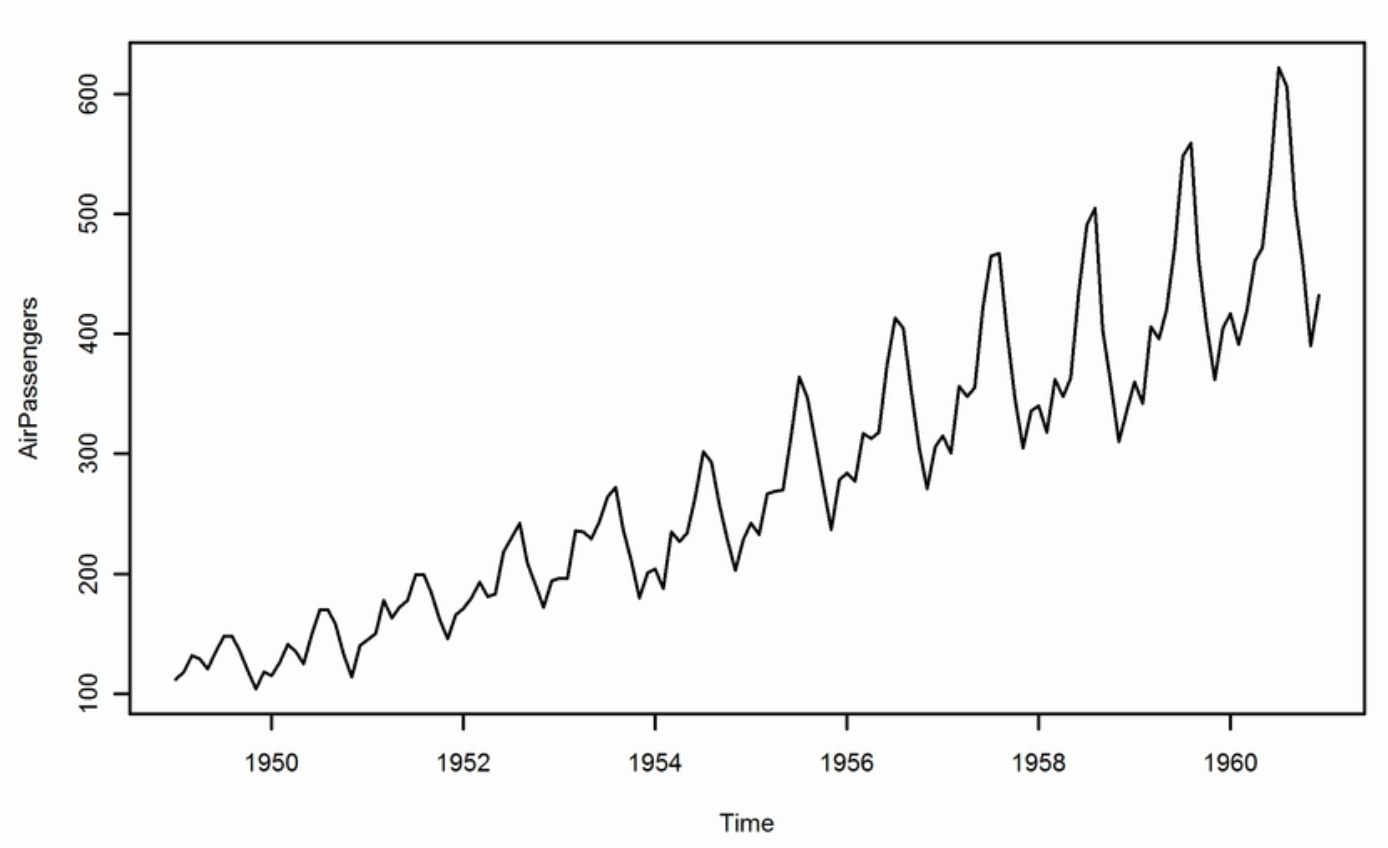

(1) 시간의존성
- 시간 순서에 따라 관측 → 순서를 바꾸면 의미 달라짐
- 과거 값이 현재 값에 영향
- 시점 간 상관관계 고려 필요

(2) 계절성과 추세
- 계절성: 일정 주기(일, 주, 월, 년)로 반복되는 변동
- 추세: 시간 흐름에 따른 장기적 증가/감소 경향

(3) 자기상관성
- 한 시점의 값이 과거 값과 통계적으로 관련 있는 성질
- 관측값들이 서로 독립적이지 않음
- 예시: 기온, 주가, 공장 생산량, 환율

자기상관성으로 인해 일반 회귀분석 사용 어려움

1. 오차항 독립성 가정 위반 → 통계 결과 왜곡
   - 기본 가정인 오차항 간 독립성 위배
   - 검정과 신뢰구간 추론 왜곡

2. 허위 상관관계 문제
   - 두 시계열이 모두 증가 추세를 가질 때 인과관계 없어도 높은 상관관계 발생
   - 해결: 차분, 추세 회귀 후 잔차 사용 등으로 추세 제거

3. 예측 어려움 및 모델 복잡성 증가
   - 잔차가 시간에 따라 패턴을 가지면 예측 왜곡
   - 시계열 전용 모델(ex. AR, MA, ARIMA 등) 필요

결론
- 일반 회귀에서는 가정을 깨뜨리는 문제
- 시계열 전용 모델에서는 자기상관성 자체를 활용해 예측

### 1.3 시계열 데이터의 분석요인

(1) 추세 요인
- 시간에 따라 지속적으로 증가/감소하는 경향
- 예: 연도별 매출 상승, 출산률 감소

(2) 계절 요인
- 일정한 주기로 반복되는 패턴
- 예: 크리스마스 시즌 관련 용품 매출 증가

(3) 순환 요인
- 계절성보다 길고 불규칙한 주기로 반복되는 변동
- 예: 경기 호황과 불황기
- 계절성 vs 순환성 구분
  - 고정된 주기 반복 → 계절성
  - 주기가 불규칙하거나 장기적 → 순환성
- 데이터가 순환 주기보다 짧으면 판단 어려워 무시하거나 추세에 포함

(4) 불규칙 요인
- 추세, 계절성, 순환성 제거 후 남은 예측 불가능한 변동
- 노이즈, 우연적 사건, 일시적 변동, 이상치 포함
- 예: 자연재해, 팬데믹
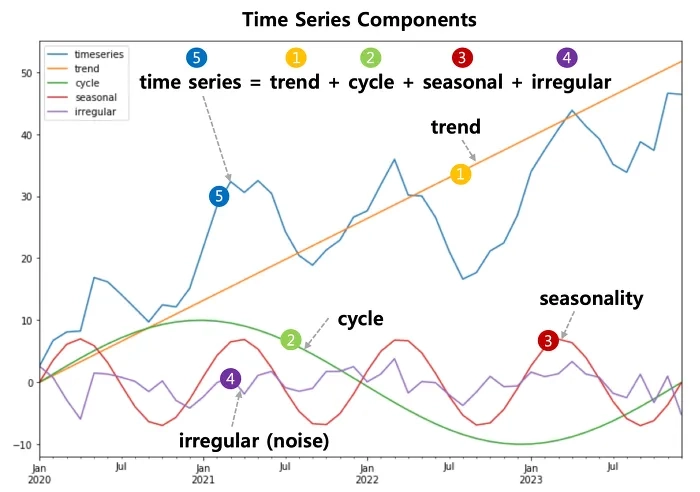
---

## 2. 시계열 데이터 전처리

전처리 프로세스
1. 데이터 확인 및 시각화
2. 결측치 확인 및 처리
3. 이상치 탐지 및 처리
4. 평활화 진행
5. 요소 분해

### 2.1 결측치/이상치 처리

#### (1) 결측치

정의
- 특정 시점에서 값이 측정되지 않거나 누락된 상태
- 원인: 센서 오류, 수집 누락, 전송 지연
- 결측치 존재 시 추세/계절성 왜곡 → 적절한 대치 필요

처리 방법

1. 삭제
   - 비어 있는 시점 데이터 제거
   - 가장 단순하지만 시간 연속성 깨짐

2. 단순 대치
   - 평균, 중앙값, 최빈값, 0으로 채움
   - 패턴 왜곡 가능성 큼

3. 보간법
   - 데이터 포인트를 사용해 누락된 값 추정
   - 결측 구간이 짧거나 패턴 단순할 때 정확도 높음

4. 머신러닝 기법

보간법 종류

1. 선형 보간법
   - 두 점 사이를 직선으로 연결
   - 장점: 빠르고 간단, 직관적
   - 단점: 비선형 관계나 급격한 변화에서 정확도 하락

2. 다항식 보간법
   - 다항식 함수로 근사
   - 장점: 복잡한 비선형 관계 모델링 가능
   - 단점: 고차 다항식에서 과적합 발생

3. 스플라인 보간법
   - 구간별 다항식 사용 (큐빅 스플라인이 일반적)
   - 장점: 부드럽고 연속적인 보간, 과적합 적음
   - 단점: 구현 복잡

4. 조각별 상수 보간법
   - 각 구간에서 동일한 상수 값 유지
   - 종류: 이전 값 유지(전방 채우기), 다음 값 유지(후방 채우기), 최근접 이웃 보간
   - 장점: 단순, 계산량 적음
   - 단점: 부드러움 없음, 계단형

보간 vs 회귀
- 회귀: 오차를 가장 적게 만드는 선 탐색 오차 허용
- 보간: 관측값 완전 신뢰, 직접 연결

#### (2) 이상치

정의
- 측정되었으나 일반적이지 않은 극단적 값
- 측정 오류이거나 실제 특이 이벤트일 수도 있음
- 신호의 중요한 의미일 가능성 → 신중한 접근 필요

이상치 탐지 방법

1. 사분위수 범위 기반 탐지
   - 장점: 단순, 해석 명확, 빠름
   - 단점: 추세나 계절성이 강한 시계열에 부적합

2. 표준점수 기반 탐지
   - 평균으로부터 몇 표준편차 떨어졌는지 측정
   - 장점: 계산 간단, 해석 직관적
   - 단점: 정규분포 가정에 민감, 비정상 시계열에서 임계값 설정 어려움

3. 계절-추세 분해 기반 탐지
   - 시계열을 추세/계절성/잔차로 분해
   - 잔차가 임계값 초과 시 이상으로 판단
   - 장점: 진짜 이상값만 잡아냄
   - 단점: 계산 비용 큼, 파라미터 튜닝 필요

이상치 탐지 모델

1. 분류 및 회귀 트리
   - 데이터 분할 → 예측값 산출 → 예측 오차로 이상치 판단
   - 장점: 비선형 관계 포착, 다변량 적용 가능
   - 단점: 노이즈 많으면 과적합

2. 클러스터링 기반 탐지
   - 정상 데이터는 클러스터에 모이고 이상치는 멀리 떨어짐
   - K-평균, 밀도 기반 클러스터링, 격리 숲 사용
   - 장점: 사전 분포 가정 불필요
   - 단점: 하이퍼파라미터에 민감

3. 오토인코더
   - 인공신경망 기반 비지도 학습
   - 정상 패턴 학습 후 복원 오차가 크면 이상치로 판정
   - 장점: 복잡한 비선형 패턴 학습
   - 단점: 학습 데이터 많이 필요, 해석 어려움

이상치 처리
- 결측치로 간주 → 삭제/단순 대치/보간 적용

### 2.2 EDA

평활화 개념
- 시계열 데이터의 노이즈를 줄여 전체 흐름을 명확하게 만드는 기술
- 노이즈: 데이터에 섞인 설명 불가능한 랜덤 변동
- 관측 데이터 = 신호 + 노이즈

이동평균
- 윈도우(구간) 내 평균을 구해 평활화 효과 획득
- 윈도우 길이가 클수록 노이즈 더 많이 제거
- 사용 목적: 노이즈 제거, 추세 파악, 예측 기초자료

이동평균 유형

1. 단순 이동평균
   - 특정 기간 데이터의 단순 평균
   - 변동이 안정적인 시계열에 적합

2. 가중 이동평균
   - 최근 데이터에 더 높은 가중치 부여
   - 최근 데이터가 중요한 상황에 적합

3. 지수 이동평균
   - 최근 데이터에 지수적으로 더 많은 가중치 적용
   - 과거 모든 데이터 고려
   - 최근 값에 빠르게 반응 필요한 시계열(주식 같은거)에 활용

활용
- 평활화 기법이지만 주변 값들의 이동평균으로 결측치/이상치 대치에도 사용

### 2.3 요소분해

개념
- 시계열 데이터를 개별 성분(ex. 추세, 계절성, 순환성, 불규칙성)으로 분해
- 각 요소를 분리해 패턴을 명확히 이해
- 예측, 이상 탐지 작업 정교화 가능
- 일반적으로 순환성은 0으로 설정

#### (1) 가법모형 / 승법모형

가법모형
- 시계열 = 추세 + 계절성 + 불규칙성
- 각 요인이 독립적으로 더해짐
- 계절성 진폭이 일정할 때 적합
- 예: 여름철 관광객이 매년 10만명씩 증가

승법모형
- 시계열 = 추세 × 계절성 × 불규칙성
- 로그 변환 시 가법 형태로 변환 가능
- 추세가 커질수록 계절성/불규칙성 효과도 비례 증가
- 진폭이 시간에 따라 달라질 때 적합
- 예: 여름철 관광객이 매년 10% 증가

#### (2) seasonal_decompose / STL

seasonal_decompose
- 전통적인 시계열 분해 기법
- 작동 방식
  1. 중심 이동평균으로 추세성분 추정
  2. 원 시계열에서 추세 제거 → 추세 제거 시계열 생성
  3. 동일 계절 인덱스 값들의 평균으로 계절 패턴 도출
  4. 잔차 산출
- 특징
  - 고정된 계절성만 반영
  - 이상치 영향 많이 받음
  - 이동평균 계산 구간만큼 앞뒤 데이터 손실

STL
- 국소 가중 산점도 평활화 사용
- 시간에 따라 변하는 계절성도 유연하게 포착
- 이상치에 강건
- 작동 방식: 내부 루프와 외부 루프의 이중 반복 구조
  - 내부 루프: 추세 제거 → 부분 계열 추출 → 국소 가중 회귀 → 저주파 성분 제거 → 계절 성분 확정 → 추세 갱신
  - 외부 루프: 잔차 크기 기준 강건성 가중치 부여
- 특징
  - 시간에 따라 변하는 계절성 반영
  - 이상치 영향 적음
  - 데이터 손실 없음

---

## 3. 정상성 판단

### 3.1 정상성의 정의

- 시간에 상관없이 일정한 성질을 띠는 것
- 평균, 분산 등 통계적 특성이 시간에 따라 일정 수준 유지
- 정상 시계열: 정상성을 띠는 시계열
- 비정상 시계열: 정상성을 띠지 않는 시계열

중요성
- 과거 패턴이 미래에도 유지될 것이라 가정 가능 → 통계 모델링에 바로 적용 가능
- 비정상 시계열은 변환 후 분석 필요

### 3.2 강한 정상성과 약한 정상성

강한 정상성
- 시간을 언제로 잡든 데이터 확률 분포 자체가 동일
- 평균, 분산, 왜도, 첨도 등 모든 통계적 특성 일정
- 현실에서는 거의 존재하지 않음

약한 정상성
1. 평균이 일정 → 시간이 지나도 일정 수준 유지
2. 분산이 일정 → 변동 폭이 일정 수준 유지
3. 자기공분산이 시차에만 의존 → 시간 간격에 의해서만 결정

공분산 vs 자기공분산
- 공분산: 서로 다른 두 변수가 함께 움직이는 정도
- 자기공분산: 동일 시계열의 서로 다른 시점 사이 관계
  - 양수: 과거와 현재가 같은 방향
  - 음수: 반대 방향
  - 0: 기억 없는 랜덤 시계열

핵심
- 언제 측정하느냐가 아니라 얼마나 떨어졌느냐만 중요

### 3.3 정상성의 판단

#### (1) 시각적 판단

정상 시계열의 특징
- 일정한 기준선(여기선 평균)을 중심으로 일정한 폭으로 진동

비정상 시계열의 특징
- 추세 존재: 데이터가 지속적으로 상승/하락 (ex. 주식 가격, 물가)
- 계절성 존재: 특정 주기로 패턴 반복 (월별 아이스크림 판매량 같은거)

차분 활용
- 추세가 뚜렷해도 차분으로 정상 시계열 변환 가능
- 예: 일일 변동량 = 오늘 가격 - 어제 가격

#### (2) 통계적 판단

단위근 개념
- 과거 충격이 영구적으로 누적되는 특성
- 비정상성의 주된 원인
- 시계열이 무작위로 움직여 평균으로 회귀하지 않음

자기회귀 1차 모형의 계수에 따른 해석
- 계수 = 0: 완전한 백색잡음, 외부 충격만으로 시계열 생성
- |계수| < 1: 정상 시계열, 외부 충격 영향이 시간 지날수록 사라짐
- 계수 = 1: 비정상 시계열, 단위근 존재, 랜덤워크 현상 (특히 주가같은거 )

증강 디키-풀러 검정
- 귀무가설: 단위근 존재 비정상 시계열
- 대립가설: 단위근 없음 정상 시계열
- p-값 < 유의수준 → 귀무가설 기각 → 정상 시계열

KPSS 검정
- 귀무가설: 단위근 없음
- 대립가설: 단위근 존재
- p-값 < 유의수준 → 귀무가설 기각 → 비정상 시계열

두 검정 결과 조합 해석
- 둘 다 정상 → 정상 시계열, 바로 모델링
- 둘 다 비정상 → 단위근 존재, 차분 적용
- ADF 비정상 + KPSS 정상 → 확정적 추세 의심, 추세 제거 또는 추세항 모델링

확정적 추세 vs 확률적 추세
- 확정적 추세: 시간에 따라 일정한 방향으로 증가/감소, 예측 가능
- 확률적 추세: 추세선 자체가 시간에 따라 이동 랜덤워크 성격임
- 확정적 추세 존재 시 두 검정 모두 추세항 포함 모델 사용

### 3.4 정상성 확보 방법

#### (1) 추세 제거 - 차분

차분
- 연이은 관측값들의 차이 계산
- 평균의 정상성 확보 방법
- 누적된 값을 빼줌으로써 정상 시계열 획득

종류
1. 1차 차분: t시점 값 - t-1시점 값, 추세 제거
2. 2차 차분: 1차 차분이 여전히 비정상일 때 한 번 더 차분
   - 보통 1차 차분만으로 충분
   - 2차 이상은 데이터 소실로 설명력 하락
3. 역차분: 차분된 데이터에 이전 시점 값을 더해 원래 값 복원
   - 분석/모델링은 차분 데이터로 진행
   - 해석 위해 원래 단위 복원 필요

#### (2) 계절성 제거 - 계절 차분

- t시점 값 - t-m시점 값m: 주기 길이
- 예: 12개월 주기 → m=12
- 차분 후 백색소음 형태로 변환 가능
- 계절성 패턴이 강하면 계절 차분을 먼저 수행
- 계절 차분 후 정상성 확보되면 1차 차분 불필요

#### (3) 분산 안정화 - 로그 변환

- 변동 폭이 점점 커지거나 작아질 때 적용
- 분산의 정상성 확보 방법
- 로그를 취하면 변화 폭이 줄어 비율적 변화 강조

한계점
- 음수나 0 처리 불가
- 분산 변화가 비선형적/복잡할 경우 부족할 수 있음

전체 시계열 분석 흐름
1. 단위근 검정으로 정상/비정상 판단
2. 비정상 유형에 따라 차분/계절 차분/로그 변환 선택
3. 정상성 확보 후 모델링 진행

---

## 4. 단변량 시계열 분석

### 4.1 안정적 시계열 분석

#### (1) 자기회귀 모델

개념
- 과거 자신의 값들을 독립변수로 삼아 현재 값 예측
- 시계열 데이터의 자기상관성 활용

차수별 모형
- p차 자기회귀 모형: 과거 p개 시점 데이터의 선형 조합으로 예측
- 1차 자기회귀 모형: 현재 값이 1시점 이전 값의 영향 받음
- 데이터 특성에 따라 1시점 = 1년, 1일, 1시간 전 등 다양

최소제곱법 회귀 vs 자기회귀 모형
- 최소제곱법 회귀
  - 목적: 독립변수가 종속변수에 미치는 영향 설명
  - 시계열 예측 시 예측값이 다음 예측에 사용되어 오차 누적 → 부정확
- 자기회귀 모형
  - 자체가 시계열 예측용 모델
  - 예측값 사용 구조가 모델 설계에 포함
  - 최대우도추정 기반 파라미터 추정

#### (2) 이동평균 모델

개념
- 평활화 기법인 이동평균과 이름만 같고 전혀 다른 개념
- 과거 시점의 잔차를 독립변수로 삼아 현재 값 예측
- 과거의 예측 오차를 현재 시점에 반영

잔차의 특성
- 실제 값과 예측 값의 차이
- 모두 백색잡음이며 서로 독립적
- 백색잡음: 평균 0, 분산 일정, 과거 값 영향 없음, 외부 충격에 의해서만 결정

차수별 모형
- q차 이동평균 모형: 과거 q개 예측 오차의 선형 결합으로 예측
- 1차 이동평균 모형: 현재 값이 1시점 이전 오차의 영향 받음

#### (3) 자기회귀와 이동평균 모델의 전제조건

조건 1: 정상성
- AR과 MA 모형은 확률적 안정성 전제로 추정 → 모델 구조도 정상성 만족 필요

AR 모형의 정상성 조건
- 특성 방정식의 모든 해의 절댓값이 1보다 커야 함
- 1차 AR 조건: 계수의 절댓값 < 1

MA 모형의 정상성 조건
- 잔차들이 이미 정상성 만족 → MA 모형도 항상 정상성 만족

참고
- ADF/KPSS는 데이터의 정상성 파악
- 모델의 정상성 확보 위해서는 특성방정식 필요

조건 2: 가역성
- MA 모형을 무한차 AR 형태로 재표현할 수 있는지 여부
- MA 모형은 과거 오차항으로 예측 → 오차항은 직접 관찰 불가
- 관측 가능한 과거값으로 표현 가능해야 안정적

AR 모형 가역성
- 처음부터 AR 형태로 표현되어 가역성 체크 불필요

MA 모형 가역성 조건
- 특성 방정식의 모든 해의 절댓값이 1보다 커야 함

#### (4) 자기회귀 이동평균 모델
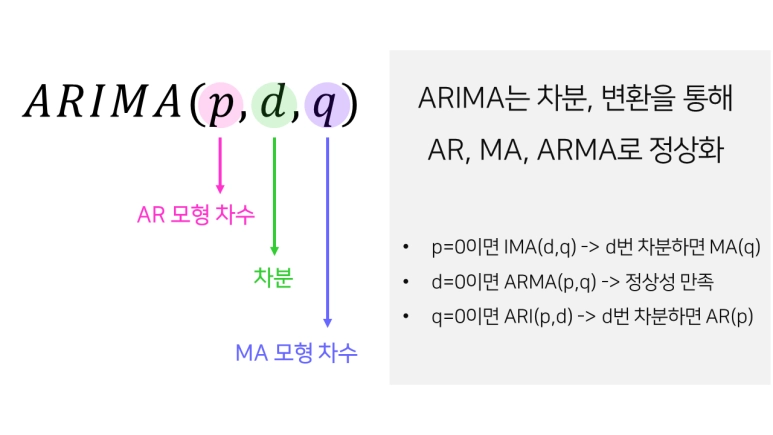

개념
- AR + MA 결합 모형
- 과거 p개 관측값 + 과거 q개 오차로 예측
- AR의 정상성 + MA의 가역성 조건 모두 만족 필요

특수한 경우
- ARMA(p, 0) = AR(p)
- ARMA(0, q) = MA(q)
- ARMA(0, 0) = 백색잡음 모델

#### (5) 차수 결정 방법 - 자기상관함수와 부분자기상관함수

자기상관함수
- 시차에 대한 두 관측치 간 상관관계 함수
- 간접 영향까지 모두 반영
- ARMA에서 q개 오차 결정에 사용

부분자기상관함수
- 시차에 대한 두 시점 사이의 순수한 상관관계 함수
- 다른 시점들의 상호 의존성 제거, 직접 영향만 분석
- ARMA에서 p개 시점 결정에 사용

차수 및 모형 결정

1. ACF: 천천히 감소 또는 진동 감소 + PACF: p+1 시점부터 0에 근접
   → AR(p) 모형, 차수 p

2. ACF: q+1 시점부터 0에 근접 + PACF: 천천히 감소 또는 진동 감소
   → MA(q) 모형, 차수 q

3. ACF: q+1 시점부터, PACF: p+1 시점부터 0에 근접
   → ARMA(p, q) 모형

그래프 패턴 해석
- AR 모형: 과거 값이 계속 영향 → ACF 천천히 감소, PACF는 p+1부터 절단
- MA 모형: 과거 오차항이 q시점까지만 영향 → ACF는 q+1부터 절단, PACF는 천천히 감소

### 4.2 불안정 시계열 분석

분석 프로세스
1. 비정상 시계열
2. 차분 또는 계절성 차분으로 정상성 확보
3. ARMA 모델로 안정적 시계열 분석

핵심
- 불안정 시계열 모델 = 안정적 시계열 모델 + 정상성 확보 과정

#### (1) 자기회귀 누적 이동평균 모델

개념
- ARMA + 차분 결합 모델
- 파라미터: p, d, q
  - p: 자기회귀 차수
  - d: 차분 정도
  - q: 이동평균 차수

특수한 경우
- ARIMA(0, 0, 0): 백색잡음
- ARIMA(p, 0, 0): AR(p)
- ARIMA(0, 0, q): MA(q)
- ARIMA(0, 1, 0) - 상수 없음: 랜덤워크
- ARIMA(0, 1, 0) - 상수 있음: 표류를 포함하는 랜덤워크

랜덤워크
- 오늘 값 = 어제 값 + 예측 불가 변화량
- 현재 값 예측의 최선 = 어제 값
- 방향성 없음
- 예: 학회비 통장 잔액이 매년 랜덤 충격만 받는 경우

표류를 포함하는 랜덤워크
- 랜덤워크 + 상수항
- 상수항이 누적되어 방향성 생김
- 예: 매년 일정 금액 추가로 받아 점점 증가

#### (2) 계절성 자기회귀 누적 이동평균 모델

개념
- 시계열 데이터의 계절성 처리 가능
- ARIMA + 계절성 변동 반영

하이퍼파라미터
- 비계절: p, d, q
- 계절: P, D, Q
- m: 계절성 주기 길이

각 파라미터 의미
- p: AR 차수
- d: 차분 정도
- q: MA 차수
- P: 계절성 AR 차수
- D: 계절성 차분 정도
- Q: 계절성 MA 차수

예시: 호빵 판매량 SARIMA(1,1,1)(1,1,1)₁₂
- 비계절 차분 1로 추세 제거
- 1개월 전 판매량/예측 오차가 현재에 영향
- 계절 차분 1로 계절성 추세 제거
- 12개월 전 판매량/예측 오차가 현재에 영향

계절성 데이터의 ACF 특징
- 계절 주기 m의 배수 시차에서 급등
- 비계절성 추세 파악 어려움 → 계절성 차분 먼저, 비계절성 차분 나중

하이퍼파라미터 결정 방법

1. d, D 차분 정도
   - ADF 검정으로 정상성 확보 여부 판단
   - 대부분 0 또는 1

2. p, q AR, MA 차수
   - ACF/PACF로 범위 추정
   - 정보 기준(AIC, BIC)으로 격자 탐색 후 최종 선택
   - 보통 0~3 범위에서 탐색
   - AIC, BIC 값이 낮을수록 모델 성능 좋음

---

## 5. 다변량 시계열 분석

### 5.1 벡터 자기회귀 모델

핵심 아이디어
- 자신의 과거 값 + 다른 변수들의 과거 값을 함께 사용해 예측

단변량 AR vs 다변량 VAR
- 단변량 AR: 변수가 자기 자신의 과거만 사용 단방향
- 다변량 VAR: 여러 변수가 서로의 과거 사용 양방향

예시
- 단변량: 2025년 GDP = 2024년 GDP로만 예측
- VAR
  - 2025년 GDP = 2024년 GDP + 2024년 소비
  - 2025년 소비 = 2024년 소비 + 2024년 GDP

적합한 경우
- 변수들이 서로 영향을 주고받는 경우
- 경제/금융 지표처럼 상호 의존성이 중요한 경우

부적합한 경우
- 변수가 너무 많은 경우 -> 파라미터 폭발
- 변수 간 관계가 명확하지 않은 경우
- 장기 예측이 필요한 경우

변수 선택: 그레인저 인과관계 검정
- X의 과거 정보가 Y의 미래 예측에 도움이 되는가
- 진짜 인과관계가 아니라 예측 가능성만 의미


검정 과정
1. 제한 모델: Y를 Y의 과거값만으로 예측
2. 비제한 모델: Y를 Y + X의 과거값으로 예측
3. 귀무가설: X는 Y 예측에 도움 안 됨
4. 대립가설: X는 Y 예측에 도움 됨

결론
- p-값 < 0.05 → VAR 모델에 포함
- p-값 ≥ 0.05 → 제외 고려

VAR 활용 분석 방법

1. 충격 반응 함수
   - 한 변수의 충격이 다른 변수에 미치는 영향을 시간 흐름에 따라 분석
   - 예: 소득에 충격 발생 시 소비 변수가 며칠 뒤 어떻게 반응

2. 예측오차 분산 분해
   - 예측 오차에 각 변수가 얼마나 기여하는지 분석
   - 예: 소비 예측 오차가 얼마나 소득/저축 충격 때문인지

---

## 6. 딥러닝을 활용한 시계열 분석

### 6.1 등장 배경

전통 통계 모델의 한계
1. 데이터가 많으면 처리 속도 저하
2. 크기가 고정된 데이터만 가능
3. 비선형 패턴 포착 어려움

→ 딥러닝으로 해결

### 6.2 순환 신경망 계열

모델 종류
- RNN: 이전 시점 정보를 현재로 전달하는 순환 구조 기본 신경망
- LSTM: 게이트 메커니즘으로 장기 기억 유지하도록 개선
- GRU: LSTM 단순화, 더 빠르게 학습하면서 비슷한 성능

적합한 경우
- 순차적 패턴이 중요한 시계열
- 과거 정보가 미래 예측에 영향을 주는 문제
- 예: 주가, 센서, 재무 데이터, 사용자 행동 로그

부적합한 경우
- 매우 긴 시계열 학습 어려움
- 병렬 처리 효율 낮음
- Transformer 계열 대비 학습 속도 느림

모델별 특징
- RNN: 간단/빠름, 장기 의존성 학습 불가 → 짧은 시계열
- LSTM: 장기 의존성 학습 가능, 복잡/느림 → 분기별 재무제표
- GRU: LSTM보다 빠름, 적당한 성능, 장기 의존성은 약함 → 실시간 센서 데이터

### 6.3 Transformer 계열

1. Informer 장기 예측 특화
   - 불필요한 연산 줄여 계산 복잡도 대폭 감소
   - 매우 긴 시계열 처리에 강력

2. Autoformer 주기성 포착 특화
   - 요소 분해를 딥러닝 구조에 결합
   - 연간 계절성 등 주기 패턴이 뚜렷한 판매량 예측에 우수

3. TFT 실무 활용도 1위
   - 과거 데이터 + 외부 변수 함께 활용
   - 어텐션 스코어로 변수 중요도 해석 가능
   - 설명력이 중요한 유통/비즈니스 수요 예측에 활용

모델별 사용 시점
- Informer: 긴 시계열 , 계산 효율적, 짧은 시계열은 과적합 위험
- Autoformer: 주기성 뚜렷, 주기 포착 우수, 구조 복잡
- TFT: 외생 변수 많음 , 해석 가능, 학습 시간 오래 걸림

### 6.4 기반 모델

개념
- 거대 데이터로 사전 학습 → 다양한 문제 해결 가능한 범용 모델
- 특정 문제 전용이 아닌 범용적
- 사전 학습 후 미세 조정으로 특화

유형
1. 대규모 언어 모델 기반: 프롬프트 엔지니어링, 미세 조정
2. 시계열 전용 기반 모델: TimeGPT, TimesFM, Moirai, Chronos

대규모 언어 모델 활용 방식
1. 적응 없는 방식: 프롬프트 엔지니어링에 집중
2. 대규모 언어 모델 적응: 시계열 데이터로 미세 조정
3. 대규모 언어 모델로의 적응: 시계열을 텍스트로 변환 후 활용

### 6.5 딥러닝 모델 선택 가이드

핵심 트레이드오프
- 단순함 vs 성능: RNN < LSTM/GRU < Transformer
- 해석 가능성 vs 정확도: 통계 모델 < 딥러닝 단, TFT는 어텐션으로 해석 가능
- 학습 시간 vs 예측 성능: 간단한 모델 빠름, 복잡한 모델 정확
- 데이터 크기: 적으면 통계/RNN, 많으면 Transformer

상황별 추천 모델
- 짧은 시계열 : 통계 모델, RNN → 과적합 방지
- 중간 길이 : LSTM, GRU → 적절한 복잡도
- 매우 긴 시계열 : Informer, Autoformer → 전역 패턴 효율 학습
- 장기 의존성 중요: LSTM, Transformer → 먼 과거 정보 유지
- 주기 패턴 뚜렷: Autoformer → 추세/계절성 분해
- 외생 변수 많음: TFT → 정적/동적 변수 융합 + 해석 가능
- 대규모 데이터: Transformer 계열 → 병렬 연산 효율
- 범용 예측 필요: 기반 모델 → 사전 학습 지식 활용

